# Task 2: Stock Price Prediction Using Machine Learning

## Objective
Predict the next day's closing stock price using historical stock market data obtained from Yahoo Finance using Machine Learning.

In [14]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Download Apple Stock Data

In [15]:

df = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


# Download Apple Stock Data

In [16]:
df.to_csv("data/stock_data.csv")

print("Dataset saved successfully.")

Dataset saved successfully.


# Exploratory Data Analysis (EDA)

In [17]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1258, 5)

Columns:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Missing Values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


# Statistical Summary

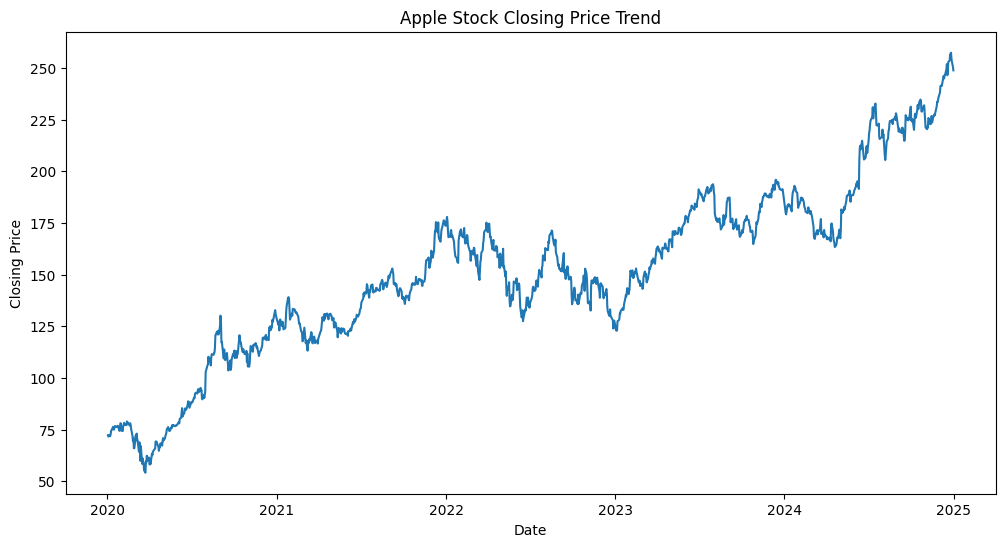

In [18]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Apple Stock Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.show()

# Feature Engineering

In [19]:
df['Target'] = df['Close'].shift(-1)

df = df.dropna()

df.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,71.630661
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,72.201416
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,71.861839
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,73.017838
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,74.568779


# Feature Selection

In [20]:
X = df[['Open', 'High', 'Low', 'Volume']]

y = df['Target']

X.head()

Price,Open,High,Low,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
2020-01-02,71.344054,72.394086,71.091184,135480400
2020-01-03,71.563228,72.389280,71.406689,146322800
2020-01-06,70.754021,72.239950,70.503554,118387200
2020-01-07,72.211041,72.466322,71.642681,108872000
2020-01-08,71.565621,73.318877,71.565621,132079200


# Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1005, 4)
Testing Shape: (252, 4)


# Model Training

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


# Generate Predictions

In [23]:
y_pred = model.predict(X_test)

print("First Five Predictions:")
print(y_pred[:5])

First Five Predictions:
[143.05369215  78.22308138  60.41245075  58.72467313 167.23492425]


# Model Evaluation

In [24]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

print("R² Score:", r2)

MAE: 2.086167824375095
MSE: 8.293554868386206
RMSE: 2.8798532720238033
R² Score: 0.9952642034357622


# Actual vs Predicted Stock Prices

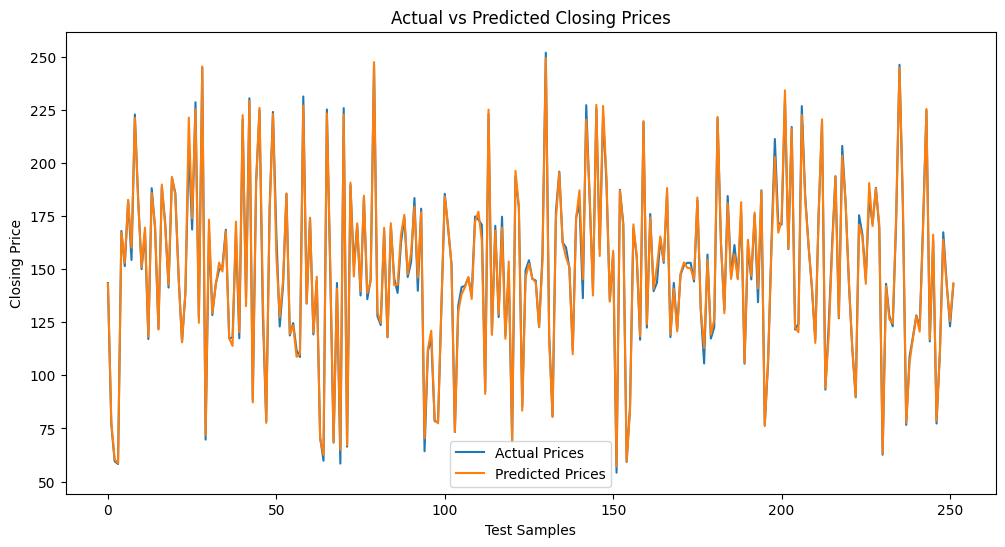

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Prices'
)

plt.plot(
    y_pred,
    label='Predicted Prices'
)

plt.title('Actual vs Predicted Closing Prices')

plt.xlabel('Test Samples')

plt.ylabel('Closing Price')

plt.legend()

plt.show()

# Save Visualization

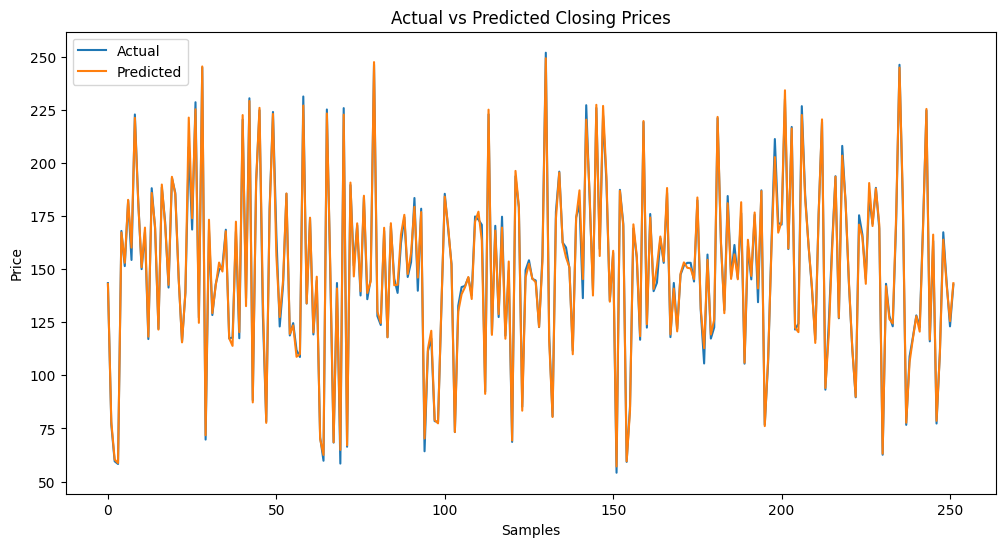

Graph saved successfully.


In [26]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(y_pred, label='Predicted')

plt.title('Actual vs Predicted Closing Prices')

plt.xlabel('Samples')

plt.ylabel('Price')

plt.legend()

plt.savefig("images/actual_vs_predicted.png")

plt.show()

print("Graph saved successfully.")